In [1]:
from chime.calibration import load_Learmonth_data
import numpy as np
import matplotlib.pyplot as plt
import chime
from scipy.optimize import curve_fit

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_017" #year naming convention
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

In [2]:

df = load_Learmonth_data("/home/scratch/dbautist/CHIME_archive/learmonthData/L250117.SRD")
df


,time,seconds,245,410,610,1415,2695,4975,8800,15400
0,2025-01-17 00:00:00+00:00,0.0,29.0,55.0,77.0,132.0,192.0,217.0,274.0,543.0
1,2025-01-17 00:00:01+00:00,1.0,32.0,56.0,77.0,133.0,191.0,216.0,269.0,541.0
2,2025-01-17 00:00:02+00:00,2.0,29.0,56.0,77.0,133.0,191.0,215.0,267.0,536.0
3,2025-01-17 00:00:03+00:00,3.0,26.0,57.0,77.0,134.0,191.0,213.0,266.0,538.0
4,2025-01-17 00:00:04+00:00,4.0,25.0,57.0,77.0,134.0,192.0,213.0,269.0,538.0
...,...,...,...,...,...,...,...,...,...,...
86395,2025-01-17 23:59:55+00:00,86395.0,44.0,68.0,80.0,150.0,213.0,249.0,280.0,545.0
86396,2025-01-17 23:59:56+00:00,86396.0,50.0,68.0,80.0,152.0,213.0,247.0,280.0,550.0
86397,2025-01-17 23:59:57+00:00,86397.0,52.0,68.0,80.0,152.0,212.0,247.0,281.0,550.0
86398,2025-01-17 23:59:58+00:00,86398.0,69.0,68.0,80.0,152.0,211.0,248.0,283.0,554.0


In [3]:
df["410"] 
freq_dfmid = np.nanmedian(df["410"] * 10000)
print(freq_dfmid)


530000.0


0        550000.0
1        560000.0
2        560000.0
3        570000.0
4        570000.0
           ...   
86395    680000.0
86396    680000.0
86397    680000.0
86398    680000.0
86399    680000.0
Name: 410, Length: 86400, dtype: float32


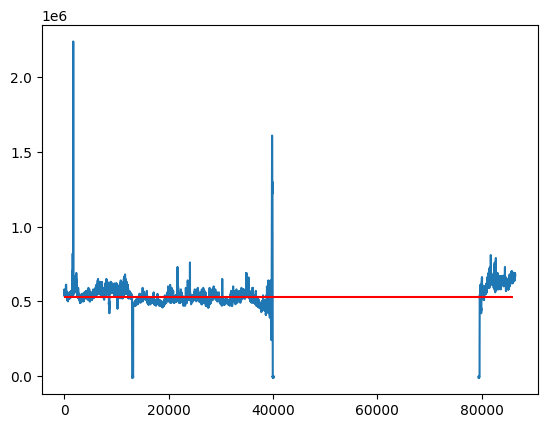

In [4]:
plt.figure()


Jy = df["410"] * 10000 

plt.plot(df["seconds"], Jy)

print(Jy)

plt.hlines(freq_dfmid, xmin=0, xmax=86000, color='red')

In [5]:
type(df["410"])

pandas.core.series.Series

In [6]:
type(df["410"].values)

numpy.ndarray

In [7]:
median = np.nanmedian(df["410"])
print(median)

53.0


[9.79283964e+06 1.92956462e+03 1.58576235e+01 1.40085370e+07]
errors:[3.59588610e+05 4.69054097e-01 6.90112196e-01 8.31160749e+04]
fit paramenters:[9.79283964e+06 1.92956462e+03 1.58576235e+01 1.40085370e+07]


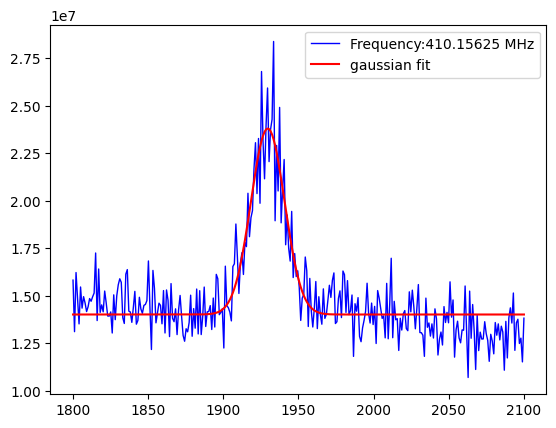

In [8]:
start = 1800
stop = 2100
#user input:

user_input = input("enter an index for frequency to read") #input statement for user to use
freq_index = int(user_input)

y = chime_data[start:stop, freq_index]
x = np.linspace(start, stop, num=len(y))

#plt.figure()
#plt.plot(x, y)

plt.figure()
def gaus_CHIME410(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

plt.plot(x, y, color="blue", linewidth=1, label=f"Frequency:{frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)

#parameter guesses:

p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME410, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit = gaus_CHIME410(x, popt[0], popt[1], popt[2], popt[3])

plt.plot(x, y_fit, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')


[7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158498e+09
 7.58158498e+09 7.58158498e+09 7.58158498e+09 7.58158499e+09
 7.58158500e+09 7.58158502e+09 7.58158505e+09 7.58158511e+09
 7.58158520e+09 7.581585

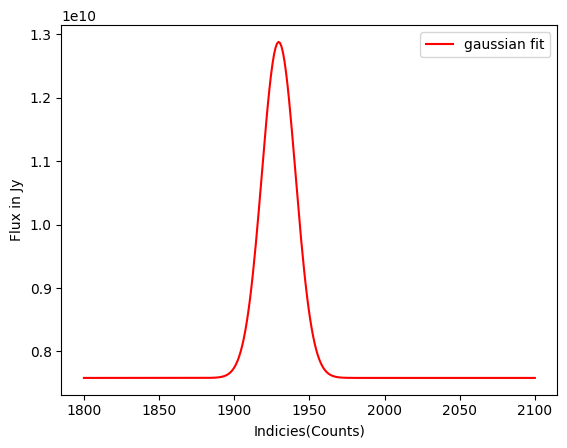

In [9]:
#calibration:

index = 25
a = popt[0]

mid_flux = freq_dfmid*10000 #converting SFU to Janskys

Fit_Jy = chime_data * (mid_flux/a) #formula for conversion where solar flux is using median for 410

converted_y = y_fit * (mid_flux/a)  #31 is the average solar flux value for 410 MHz (34 is the median)
print(converted_y)
y = chime_data[start:stop, freq_index]
Jy_iny = y * (mid_flux/a)
print(np.median(converted_y))

#plotting the fitted Jy

plt.plot(x, converted_y, color='red', label='gaussian fit')
plt.ylabel("Flux in Jy")
plt.xlabel('Indicies(Counts)')
plt.legend()
print(f'fit paramenters:{popt}')


[5.29998187e+09 1.92956460e+03 1.58577514e+01 7.58158268e+09]
errors:[1.94607929e+08 4.69080243e-01 6.90152636e-01 4.49837316e+07]
fit paramenters:[9.79283964e+06 1.92956462e+03 1.58576235e+01 1.40085370e+07]


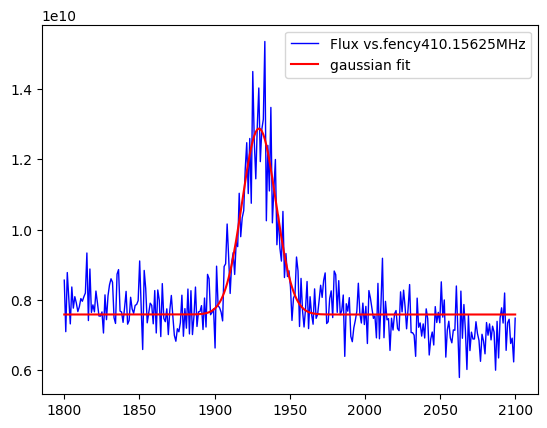

In [10]:
#Raw data(converted to Janskys):

y = chime_data[start:stop, freq_index]
CHIME_mid = np.median(converted_y)
CHIME_std = np.std(converted_y)

converted_raw_y = y * (mid_flux/a)

def Jansky_CHIME_Fit(x, a, CHIME_mid_Jy, CHIME_std_Jy, d):
    return a * np.exp(-(x-CHIME_mid_Jy)**2/(CHIME_std_Jy)**2)+d


plt.plot(x, converted_raw_y, color='blue', linewidth=1, label=f"Flux vs.fency{frequency[freq_index]}MHz")

#parameter guesses:

p0 = (280000, 1925, 75, 180000)

#fitting:

popt_raw, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_raw_y, p0=p0)
print(popt_raw)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = Jansky_CHIME_Fit(x, popt_raw[0], popt_raw[1], popt_raw[2], popt_raw[3])

plt.plot(x, y_fit_Jy, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')


[9.79283964e+06 1.92956462e+03 1.58576235e+01 1.40085370e+07]
errors:[3.59588610e+05 4.69054097e-01 6.90112196e-01 8.31160749e+04]
[ 5.30000050e+09  1.92956462e+03 -1.58576200e+01  7.58158504e+09]
errors:[1.94613739e+08 4.69053388e-01 6.90111098e-01 4.49833886e+07]


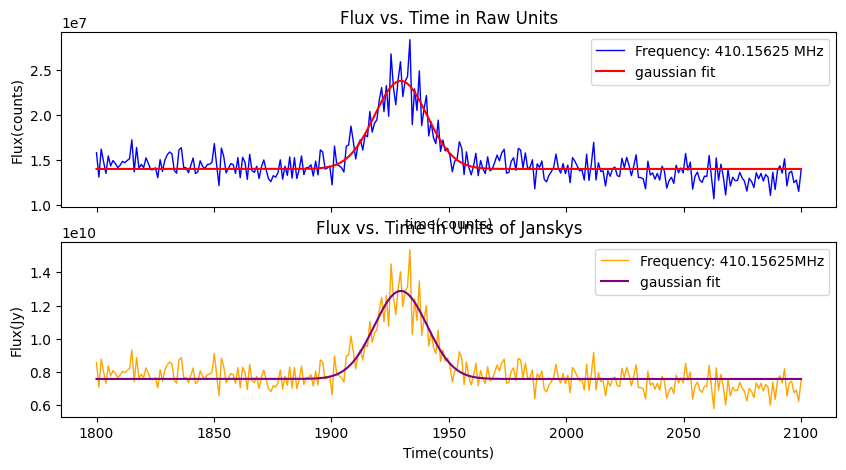

In [11]:
#Combining the two different plots:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10,5), sharex='col') #for multiple graphs to exist

def gaus_CHIME410(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

ax1.plot(x, y, color="blue", linewidth=1, label=f"Frequency: {frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)
    
#Units are in counts:
p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME410, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit = gaus_CHIME410(x, popt[0], popt[1], popt[2], popt[3])

ax1.plot(x, y_fit, color='red', label='gaussian fit')
ax1.legend()
ax1.set_xlabel("time(counts)")
ax1.set_ylabel("Flux(counts)")
ax1.set_title("Flux vs. Time in Raw Units")

##############################################################################
#code for converted units to Janskys:

def Jansky_CHIME_Fit(x, a, CHIME_mid_Jy, CHIME_sd_Jy, d):
    return a * np.exp(-(x-CHIME_mid_Jy)**2/(CHIME_sd_Jy)**2)+d


ax2.plot(x, converted_raw_y, color='orange', linewidth=1, label=f"Frequency: {frequency[freq_index]}MHz")

#parameter guesses:

p0 = (280000, 1925, 50, 180000)

#fitting:

popt_Jy, pcov = curve_fit(Jansky_CHIME_Fit, x, converted_raw_y, p0=p0)
print(popt_Jy)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit_Jy = Jansky_CHIME_Fit(x, popt_Jy[0], popt_Jy[1], popt_Jy[2], popt_Jy[3])

ax2.plot(x, y_fit_Jy, color='purple', label='gaussian fit')
ax2.legend()
ax2.set_xlabel("Time(counts)")
ax2.set_ylabel("Flux(Jy)")
ax2.set_title("Flux vs. Time in Units of Janskys")

plt.savefig("Flux vs Time.png")